# Crossover Resolution Under Different Transition Matrices

The same crossover experiment as `crossover.ipynb`, run over a catalogue of transition
matrices $T$ from `kuramoto_transition` instead of the single hard-wired successor chain.

## The problem

Two length-3 sequences share their middle pattern:

$$A: M_1 \rightarrow \xi^0 \rightarrow M_2 \qquad B: M_3 \rightarrow \xi^0 \rightarrow M_4$$

$\xi^0$ is one pattern stored twice, at $A[1]$ and $B[1]$. Cued from $A[0]$, the
trajectory reaches the crossover and then has to *choose*: the state at $\xi^0$ is
identical whichever branch brought it there, so under the plain $\mu \rightarrow \mu+1$
chain the drive toward $A[2]$ and toward $B[2]$ is symmetric and the branch is decided by
noise and $\omega$ disorder rather than by history. That is the failure this notebook
measures, and the question is which $T$ repairs it.

## $T$ Transitional matrix

$$\dot{\theta}_i = -\sin\theta_i \sum_{a=1}^{K}\sum_{\alpha=1}^{P} \xi_i^{a,\alpha}
  \sum_{\beta=1}^{P} T^a_{\alpha\beta}\,\bigl(m_i^{a,\beta}\bigr)^d$$

pattern $\alpha$ can be driven by *any* set of patterns $\beta$, not only its
immediate predecessor. If $A[2]$ is driven
partly by $A[0]$ — a pattern that is **not** shared with $B$ — the branch carries
information past the ambiguous centre. Every candidate below is one choice of which
$\beta$'s get to vote, and with what weight.



### Note on implementation

A T = (P,P) matrix gets cast into a T = (K,P,P) tensor, just the same for every one of the K sequences.

In [ ]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import kuramoto.kuramoto_library as krm
import kuramoto.transition_matrix.kuramoto_transition as ktr

In [2]:
# Same configuration as crossover.ipynb, so the baseline row below is directly
# comparable to that notebook's numbers.
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_mean=0.0,
    frequency_std=0.3,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.8,
    mode="ode",
)

N = 100
M = 10           # trials per transition matrix (each runs 2 cueing attempts)
P = 3            # patterns per sequence: M1 -> origin -> M2
MARGIN = 0.01
SEED_POOL = 10_000

# frequency_std must stay > 0: an exact, uncorrupted cue has theta in {0, pi}, so
# sin(theta_i) = 0 and the drive term vanishes identically -- with omega = 0 the
# trajectory is frozen at the cue and every rule scores "incomplete".
assert CONFIG["frequency_std"] > 0

## Build one crossover trial

Unchanged from `crossover.ipynb`: one random origin, four independent mutations of it,
two sequences sharing the origin as their centre. `sequence_from_patterns` is what allows
the same array object to sit in both sequences.

In [3]:
def make_crossover_multisequence1(N, corruption_rate, origin_seed, mutation_seeds):
    rng = np.random.default_rng(origin_seed)
    origin = rng.choice([0.0, np.pi], size=N)  # the shared crossover pattern

    M1, M2, M3, M4 = [
        krm.corrupt_phase(origin, corruption_rate, np.random.default_rng(s))
        for s in mutation_seeds
    ]

    multi = krm.MultiSequence()
    multi.add(krm.sequence_from_patterns("A", [M1, origin, M2]))
    multi.add(krm.sequence_from_patterns("B", [M3, origin, M4]))
    return multi

# this one follows the 1-1-1 cueing for crossing


def make_crossover_multisequence2(N, corruption_rate, origin_seed, mutation_seeds):
    rng = np.random.default_rng(origin_seed)
    origin = rng.choice([0.0, np.pi], size=N)  # the shared crossover pattern

    M1, M2, M3, M4, M5, M6, M7, M8 = [
        krm.corrupt_phase(origin, corruption_rate, np.random.default_rng(s))
        for s in mutation_seeds
    ]

    multi = krm.MultiSequence()
    multi.add(krm.sequence_from_patterns("A", [M1, M2, origin, M3, M4]))
    multi.add(krm.sequence_from_patterns("B", [M5, M6, origin, M7, M8]))
    return multi




def classify(retrieved, multi, name):
    """Outcome of one cueing attempt, on crossover.ipynb's criterion: a recall counts only
    if all three patterns come back in order, so retrieved[2] must exist and be the cued
    sequence's own last label. A two-label 0 -> 2 trace has skipped the shared centre and
    is not a recall of the sequence, however cleanly it ends."""
    other = "B" if name == "A" else "A"
    if len(retrieved) < 3:
        return "incomplete"
    if retrieved[2] == multi[name].labels()[2]:
        return "correct"
    if retrieved[2] == multi[other].labels()[2]:
        return "crossed"
    return "incomplete"


def run_trial(net, rng):
    """One crossover instance, cued once from each sequence's first pattern."""
    origin_seed = int(rng.integers(SEED_POOL))
    mutation_seeds = rng.choice(SEED_POOL, size=4, replace=False).tolist()
    multi = make_crossover_multisequence1(N, CONFIG["corruption_rate"], origin_seed, mutation_seeds)

    out = {}
    for name in ("A", "B"):
        result = net.simulate(multi, cue=multi[name], cue_idx=0)
        retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)[:3]
        out[name] = dict(result=result, retrieved=retrieved,
                         outcome=classify(retrieved, multi, name))
    return multi, out

## The transition catalogue

Six rules over $P = 3$ patterns. All use `boundary="self"`, so the terminal pattern
self-couples and the trajectory settles there instead of looping back into the crossover.

| rule | what it says |
|---|---|
| `chain` | $\mu \rightarrow \mu+1$. The existing `xi_next` dynamics, reproduced exactly. Baseline. |
| `skip` | $\mu \rightarrow \mu+2$. Row 1 of its matrix is identically zero, so the shared centre is never *driven* at all — `crossover.ipynb`'s `HopNetwork`, as one matrix. Present as the reference for what sidestepping the crossover looks like; see the note under the results, because what it actually decodes is not what you would guess. |
| `chain + dwell` | $\gamma I + \kappa\Sigma$. Adds symmetric self-coupling, so each pattern is something to sit in. Tests whether inertia alone holds the branch. $\gamma$ is kept small deliberately — see the note under the results. |
| `chain + skip` | $\Sigma + w\,\Sigma^{(2)}$. Visits the centre **and** lets $A[0]$ vote directly for $A[2]$. The hypothesis: an unshared predecessor carries the branch across. |
| `decay` | every earlier pattern drives every later one, weight $w^{\alpha-\beta-1}$. The same idea taken to all lags, written with `transition_from_function`. |
| `static` | $\gamma I$ only. No sequence at all — a control that should never traverse. |

In [4]:
def decay_rule(alpha, beta, w=0.5):
    """Every earlier pattern drives every later one, decaying with the lag."""
    if alpha > beta:
        return w ** (alpha - beta - 1)
    if alpha == beta == P - 1:      # settle on the terminal pattern
        return 1.0
    return 0.0


CATALOGUE = {
    "chain":        ktr.shift_transition(P),
    "skip":         ktr.shift_transition(P, nhop=2),
    "chain+dwell":  ktr.mixed_transition(P, gamma=0.1, kappa=1.0),
    "chain+skip":   ktr.shift_transition(P) + 0.5 * ktr.shift_transition(P, nhop=2),
    "decay":        ktr.transition_from_function(P, decay_rule),
    "static":       ktr.static_transition(P, gamma=1.0),
}

for name, T in CATALOGUE.items():
    print(f"{name}\n{T}\n")

chain
[[0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 1.]]

skip
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]

chain+dwell
[[0.1 0.  0. ]
 [1.  0.1 0. ]
 [0.  1.  1.1]]

chain+skip
[[0.  0.  0. ]
 [1.  0.  0. ]
 [0.5 1.5 1.5]]

decay
[[0.  0.  0. ]
 [1.  0.  0. ]
 [0.5 1.  1. ]]

static
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]



### Reading the matrices

`T[alpha, beta]` is *"$\beta$ drives $\alpha$"* — row is the destination, column the
source. So the successor chain is **sub**diagonal, and column 2 of `chain` holds the
`boundary="self"` clamp (`T[2,2] = 1`) that makes the terminal pattern hold. Swapping
that single entry to `T[0,2] = 1` is the whole difference between settling and cycling.

## Validation: `chain` must reproduce the baseline exactly

`shift_transition(P)` is the `xi_next` successor chain written as a matrix, so
`TransitionNetwork` under it and the stock `KuramotoNetwork` should integrate the same
trajectory. Any difference here means the extension changed the dynamics rather than
generalizing them.

In [5]:
check_multi = make_crossover_multisequence1(N, CONFIG["corruption_rate"], 1, [2, 3, 4, 5])

base_net  = krm.KuramotoNetwork(N=N, seed=10, **CONFIG)
chain_net = ktr.TransitionNetwork(transition=CATALOGUE["chain"], N=N, seed=10, **CONFIG)

ref = base_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)
new = chain_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)

print("history shapes:", ref["theta_history"].shape, new["theta_history"].shape)
print("max |dtheta|  :", np.abs(ref["theta_history"] - new["theta_history"]).max())

history shapes: (601, 100) (601, 100)
max |dtheta|  : 4.440892098500626e-15


## Sweep

Every rule gets a freshly seeded `default_rng(0)`, so all six see the *same* sequence of
crossover instances and the comparison is paired rather than confounded by which random
patterns each happened to draw.

In [6]:
outcomes = {}      # rule -> Counter over the 2*M cueing attempts
first_trial = {}   # rule -> (multi, out) for trial 0, kept for the plots below

for rule, T in CATALOGUE.items():
    net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
    rng = np.random.default_rng(0)     # identical instances for every rule

    counter = Counter()
    for trial in range(M):
        multi, out = run_trial(net, rng)
        if trial == 0:
            first_trial[rule] = (multi, out)
        for name in ("A", "B"):
            counter[out[name]["outcome"]] += 1

    outcomes[rule] = counter
    print(f"{rule:12s} correct={counter['correct']:3d}  crossed={counter['crossed']:3d}  "
          f"incomplete={counter['incomplete']:3d}   (of {2 * M})")

chain        correct=  7  crossed= 13  incomplete=  0   (of 20)


skip         correct=  0  crossed=  0  incomplete= 20   (of 20)


chain+dwell  correct=  5  crossed=  8  incomplete=  7   (of 20)


chain+skip   correct= 13  crossed=  6  incomplete=  1   (of 20)


decay        correct= 11  crossed=  8  incomplete=  1   (of 20)


static       correct=  0  crossed=  0  incomplete= 20   (of 20)


## Results

In [7]:
total = 2 * M
print(f"{'rule':<14}{'correct':>9}{'crossed':>9}{'incomplete':>12}")
print("-" * 44)
for rule, counter in outcomes.items():
    print(f"{rule:<14}{counter['correct'] / total:>9.0%}"
          f"{counter['crossed'] / total:>9.0%}{counter['incomplete'] / total:>9.0%}")

rule            correct  crossed  incomplete
--------------------------------------------
chain               35%      65%       0%
skip                 0%       0%     100%
chain+dwell         25%      40%      35%
chain+skip          65%      30%       5%
decay               55%      40%       5%
static               0%       0%     100%


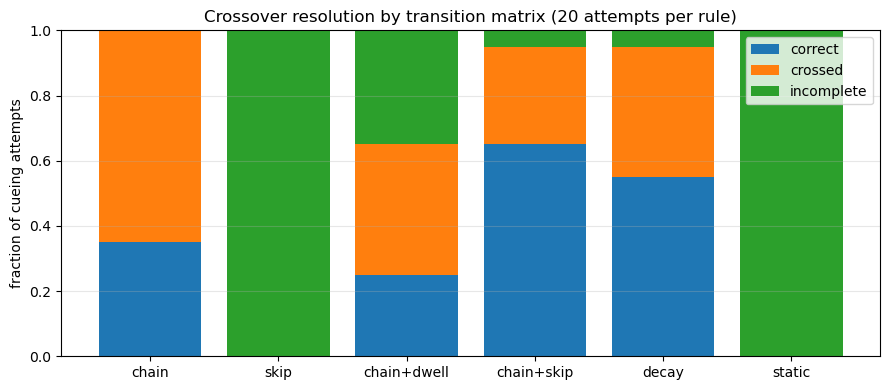

In [8]:
rules = list(outcomes)
kinds = ["correct", "crossed", "incomplete"]

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(rules))
for kind in kinds:
    heights = np.array([outcomes[r][kind] / total for r in rules])
    ax.bar(rules, heights, bottom=bottom, label=kind)
    bottom += heights

ax.set_ylabel("fraction of cueing attempts")
ax.set_title(f"Crossover resolution by transition matrix ({total} attempts per rule)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Note on `skip`: a decoded label is not a driven pattern

`skip`'s matrix has zero rows for patterns 0 and 1 — nothing in the dynamics ever drives
the shared centre. Yet it still returns three-label traces in most attempts, and so scores
well above zero. That is geometry, not recall.

$A[0]$, $A[2]$ and the origin are all corruptions of the same vector, so the origin sits
*between* $A[0]$ and $A[2]$ in overlap space. The trajectory from one to the other passes
through a region of high origin-overlap on the way, and `decode_sequence_online` duly logs
`('A', 1)` as it goes past. The label appears without the pattern ever having been a target
of the drive.

So a three-label trace certifies that the decoder saw the middle pattern, not that the rule
routed through it. Both `skip` and `chain+skip` land near 70-75% here and are not separable
at this sample size; the difference between them is visible in the traces, not the counts.

### Note on `chain+dwell`

$\gamma$ is set to 0.1 because the dwell term has no useful operating point here. Raising
it converts *crossed* into *incomplete* rather than into *correct* — by $\gamma = 0.3$
every attempt freezes on the cue, since with $d = 3$ the self-drive on the cued pattern
outweighs the advance term and the trajectory never leaves. Symmetric self-coupling makes
patterns stickier; it does not tell the network which branch it arrived from. That is the
substantive negative result of this sweep, and it is what motivates the scan below: the
disambiguating information has to come from an *unshared predecessor*, not from inertia.

## Scanning the skip weight

`chain+skip` is $\Sigma + w\,\Sigma^{(2)}$: the ordinary chain plus a direct vote from
two patterns back. At the crossover, $A[2]$ then receives drive from both $\xi^0$
(shared, ambiguous) and $A[0]$ (unshared, decisive), and $w$ sets how loudly the
unshared one speaks. $w = 0$ is exactly the `chain` baseline, so this scan interpolates
from it.

In [9]:
WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]

skip_scan = {}
for w in WEIGHTS:
    T = ktr.shift_transition(P) + w * ktr.shift_transition(P, nhop=2)
    net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
    rng = np.random.default_rng(0)      # same instances again, for every w

    counter = Counter()
    for _ in range(M):
        multi, out = run_trial(net, rng)
        for name in ("A", "B"):
            counter[out[name]["outcome"]] += 1

    skip_scan[w] = counter
    print(f"w={w:<5} correct={counter['correct'] / total:.0%}  "
          f"crossed={counter['crossed'] / total:.0%}  incomplete={counter['incomplete'] / total:.0%}")

w=0.0   correct=35%  crossed=65%  incomplete=0%


w=0.25  correct=40%  crossed=55%  incomplete=5%


w=0.5   correct=65%  crossed=30%  incomplete=5%


w=0.75  correct=65%  crossed=25%  incomplete=10%


w=1.0   correct=70%  crossed=20%  incomplete=10%


w=1.5   correct=65%  crossed=10%  incomplete=25%


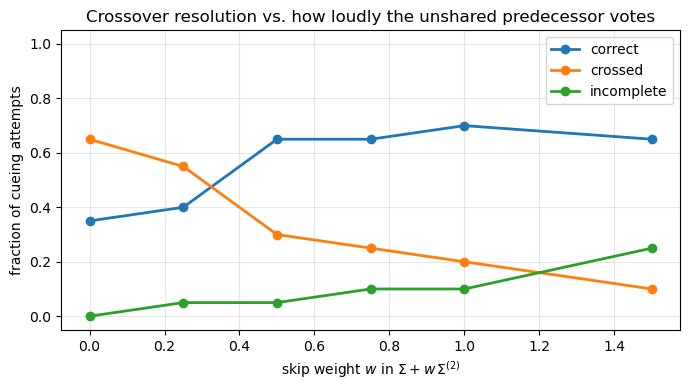

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for kind in kinds:
    ax.plot(WEIGHTS, [skip_scan[w][kind] / total for w in WEIGHTS],
            marker="o", linewidth=2, label=kind)

ax.set_xlabel(r"skip weight $w$ in $\Sigma + w\,\Sigma^{(2)}$")
ax.set_ylabel("fraction of cueing attempts")
ax.set_title("Crossover resolution vs. how loudly the unshared predecessor votes")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Trial 0 under every rule

The same crossover instance, driven six ways. Read the middle of each trace: under
`chain` the two terminal patterns rise together out of the shared centre, which is the
ambiguity itself made visible.

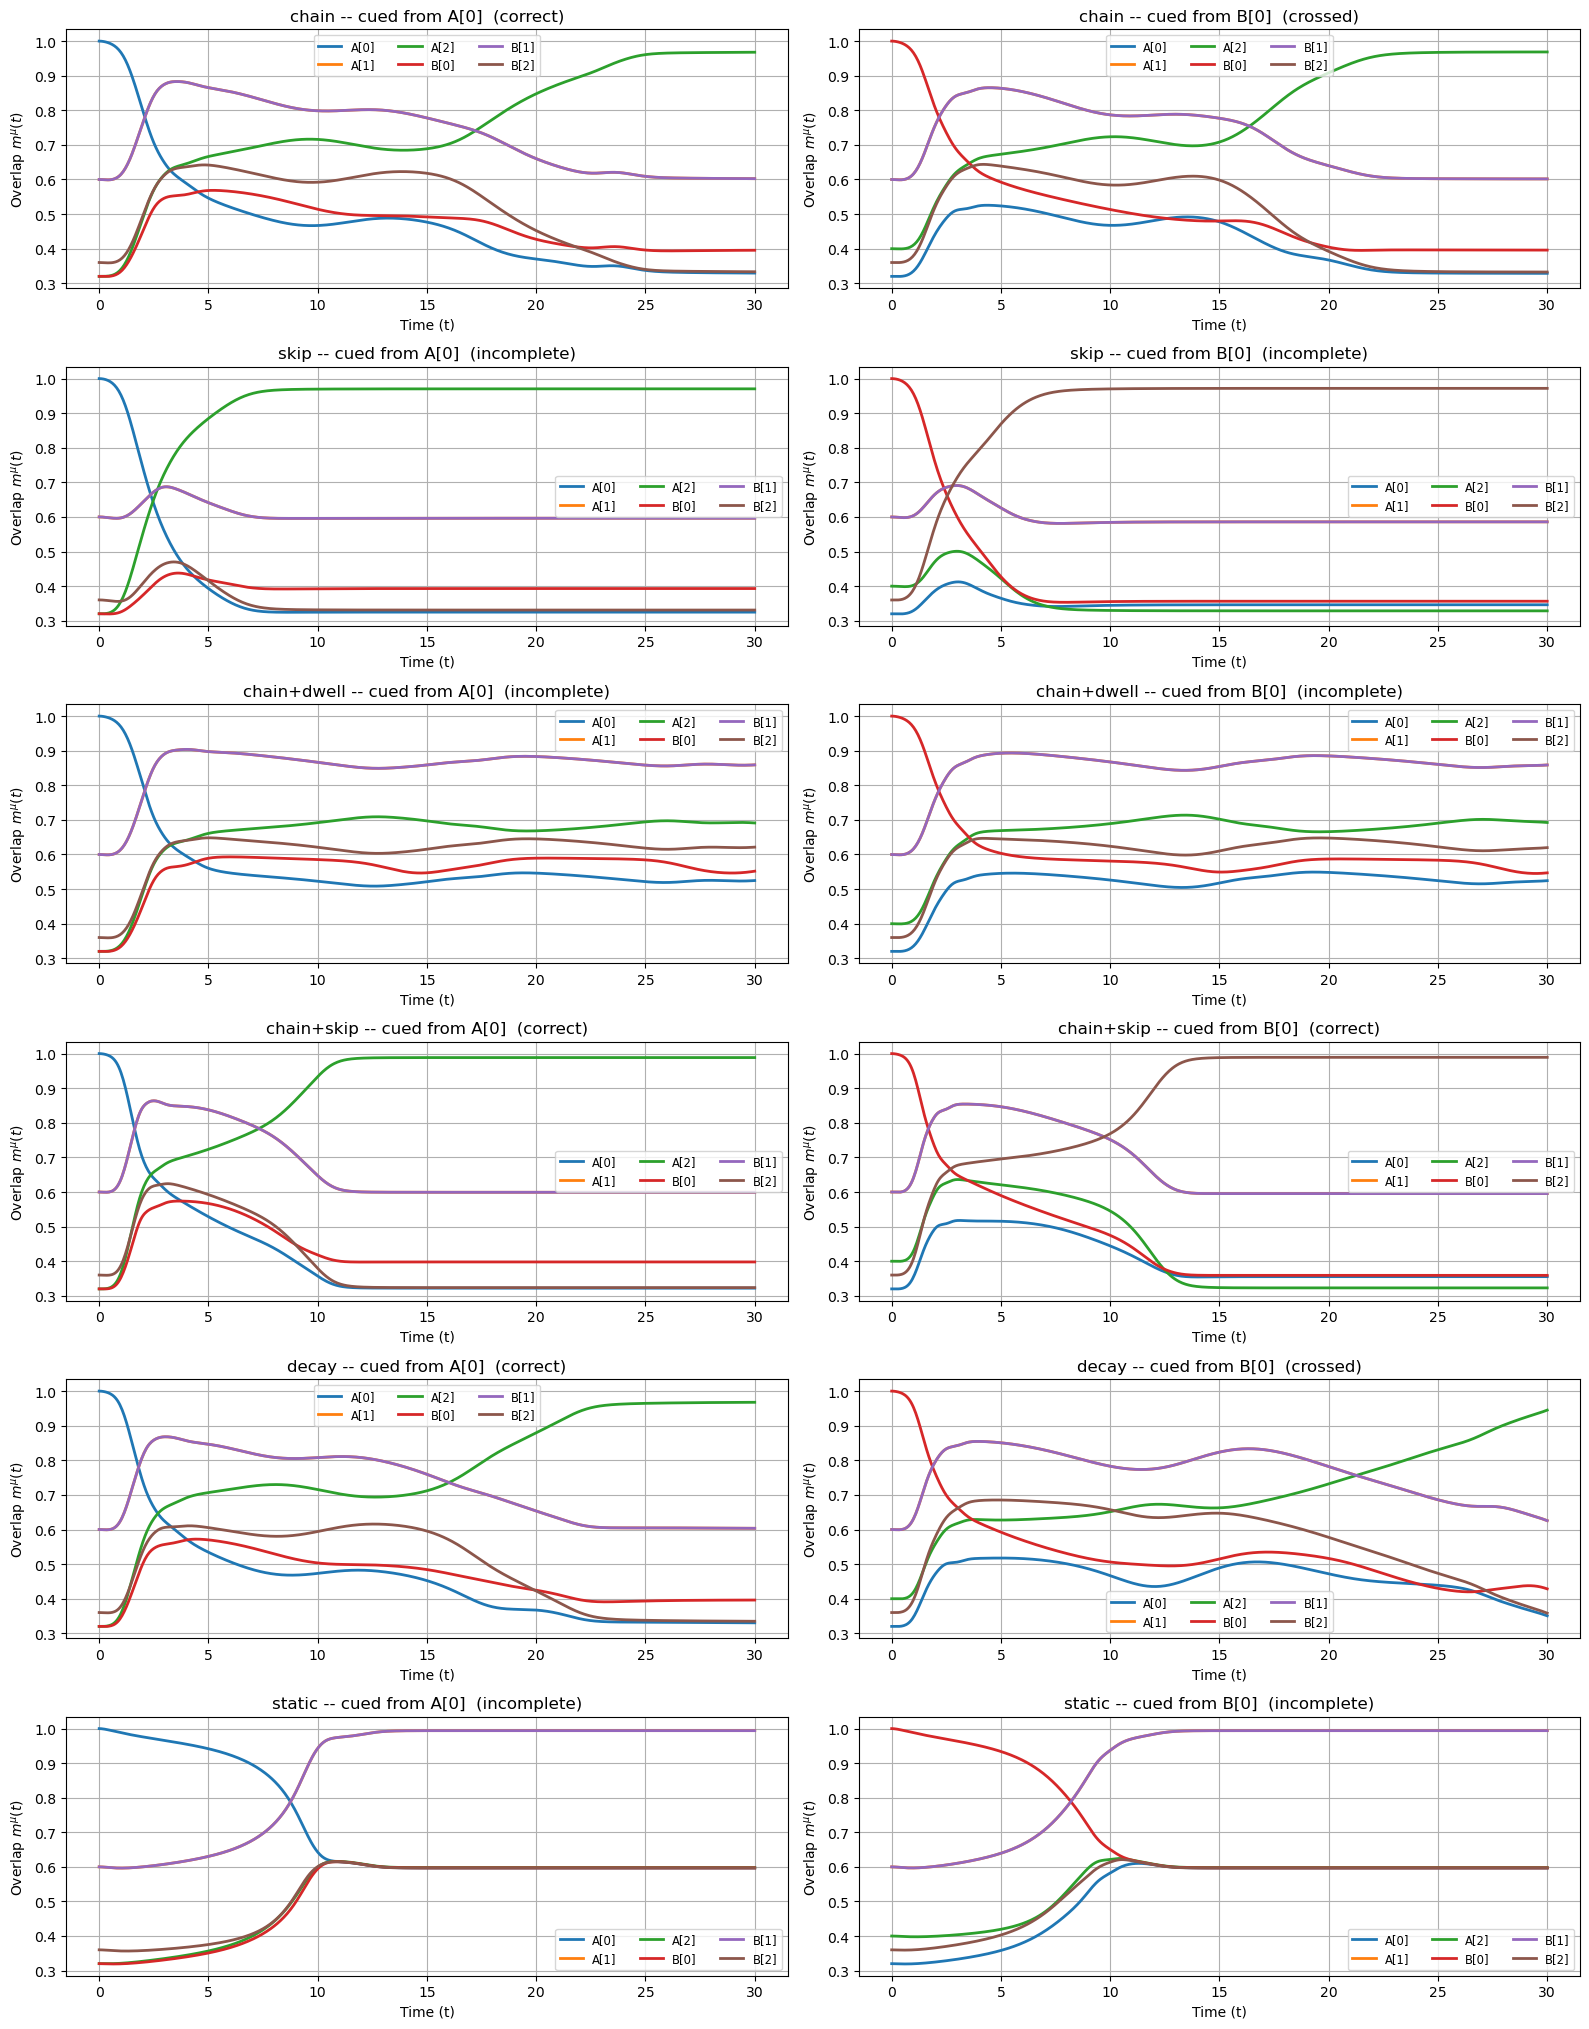

In [11]:
fig, axes = plt.subplots(len(CATALOGUE), 2, figsize=(16, 3.4 * len(CATALOGUE)))

for row, (rule, (multi, out)) in enumerate(first_trial.items()):
    net = ktr.TransitionNetwork(transition=CATALOGUE[rule], N=N, seed=10, **CONFIG)
    for col, name in enumerate(("A", "B")):
        net.plot(out[name]["result"], multi, ax=axes[row, col],
                 title=f"{rule} -- cued from {name}[0]  ({out[name]['outcome']})")

plt.tight_layout()
plt.show()

## Appendix: `skip` on its own

The `skip` row is the one whose number most needs looking at rather than reading, since
its matrix never drives the shared centre yet its traces keep producing a middle label.
These panels are just that rule.

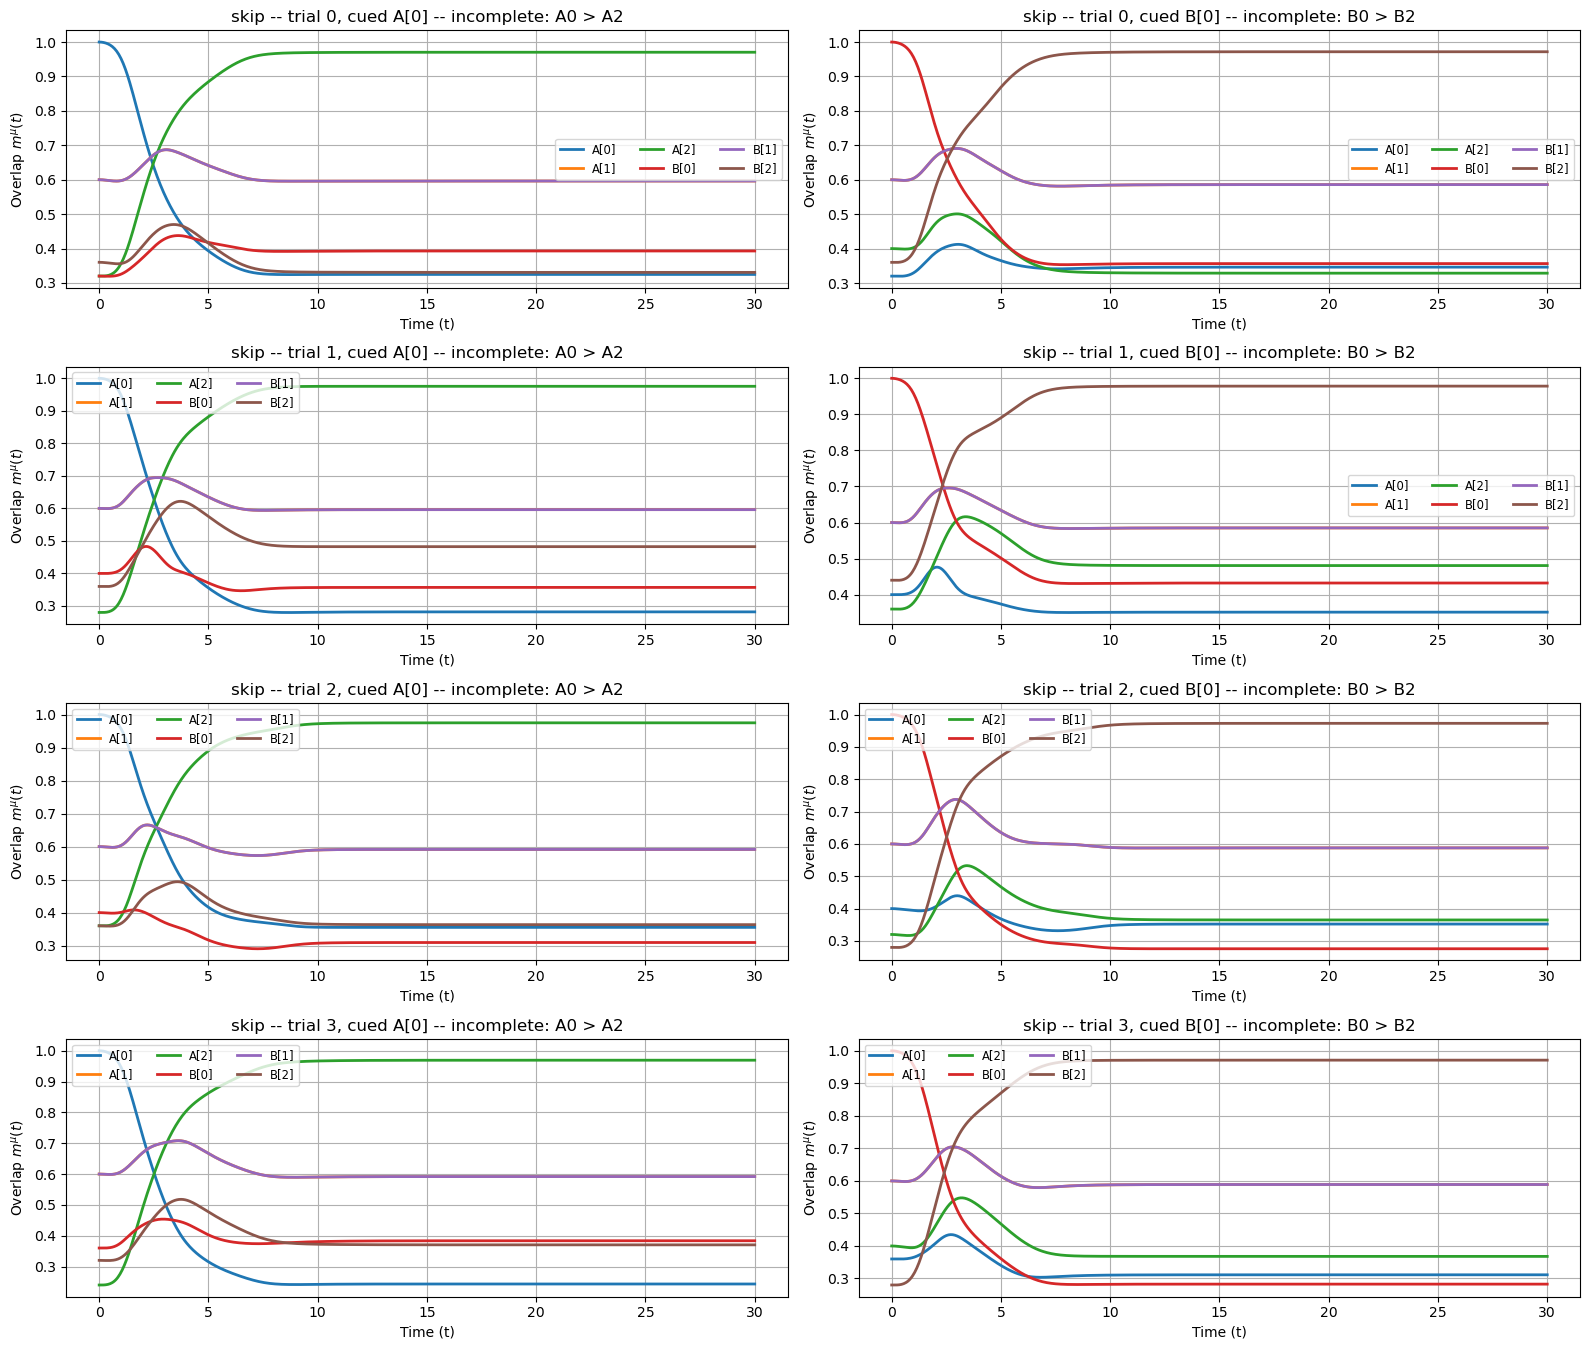

In [12]:
def path_str(retrieved):
    return " > ".join(f"{name}{idx}" for name, idx in retrieved)


SKIP_TRIALS = 4

skip_net = ktr.TransitionNetwork(transition=CATALOGUE["skip"], N=N, seed=10, **CONFIG)
skip_rng = np.random.default_rng(0)     # same instances as every sweep above

fig, axes = plt.subplots(SKIP_TRIALS, 2, figsize=(16, 3.4 * SKIP_TRIALS))
for trial in range(SKIP_TRIALS):
    multi, out = run_trial(skip_net, skip_rng)
    for col, name in enumerate(("A", "B")):
        entry = out[name]
        skip_net.plot(entry["result"], multi, ax=axes[trial, col],
                      title=f"skip -- trial {trial}, cued {name}[0] -- "
                            f"{entry['outcome']}: {path_str(entry['retrieved'])}")

plt.tight_layout()
plt.show()

## Where to change things

- **Which $T$'s are compared** — the `CATALOGUE` dict. Add an entry and every cell below
  picks it up.
- **Settle vs. loop at the last pattern** — `boundary="self"` (default) or `"cycle"` on
  `shift_transition` / `mixed_transition`. With `"cycle"` the "last label reached" score
  stops meaning anything, so switch to `decode_sequence_peaks` if you go that way.
- **Skip length** — `nhop` on `shift_transition`.
- **Dwell/advance balance** — `gamma` and `kappa` on `mixed_transition`.
- **Skip weight in `chain+skip`** — the `0.5` coefficient, and `WEIGHTS` for the scan;
  this is the main dial for the hypothesis under test.
- **Decay rate** — `w` in `decay_rule`.
- **Sharpening exponent** — `d` in `CONFIG` (on the network, not in $T$).
- **Disorder / noise** — `frequency_std`, and `phase_noise` with `mode="sde"`.
- **Statistics** — `M`. Each trial is two integrations; the whole sweep is
  `6 * 2 * M` runs.

---

# Part II — The transition-matrix rule family

The catalogue above is six matrices picked by hand. They are all members of one family, and
this part sweeps that family instead of sampling it.

The family is skips of different lengths and their weighted sums, nothing more. That is the
scope on purpose: a transition matrix can hold *which* patterns vote for the next one and
*how loudly*, and it cannot hold anything else, so those are the only two things swept.

Every rule here is built from two primitives, both already in `kuramoto_transition`:

$$\Sigma^{(k)} = \texttt{ktr.shift\_transition(P, nhop=k)}\quad\text{---}\quad T[\mu{+}k,\mu]=1,
\qquad
I = \texttt{ktr.static\_transition(P)}\quad\text{---}\quad T[\mu,\mu]=1$$

$\Sigma \equiv \Sigma^{(1)}$ is the successor chain, $\Sigma^{(k)}$ for $k \ge 2$ is a skip of
$k$ patterns, and $I$ is the static/dwell term. A rule is a weighted sum of them:

$$\boxed{\;T \;=\; \gamma I \;+\; \sum_{k\ge 1} w_k\,\Sigma^{(k)}\;}$$

so there are exactly three things to choose: **which hops appear**, **what weight each
carries**, and **how much dwell**. Part I fixed all three per rule. Part II varies them.

All matrices are normalized to unit total weight, so the overall drive does not change when
more terms are added and the rows below stay comparable to Part I's.

## The members

| name | matrix | what it says |
|---|---|---|
| `chain` | $\Sigma$ | $\mu \rightarrow \mu+1$. Part I's baseline, unchanged. |
| `skip nhop=2` | $\Sigma^{(2)}$ | $\mu \rightarrow \mu+2$. Part I's `skip`. Never drives the shared centre. |
| `static` | $I$ | Every pattern drives itself. No sequence at all; the control that should never traverse. |
| `chain+dwell` | $\gamma I + \Sigma$ | Advance plus inertia. Part I's `chain+dwell`, $\gamma = 0.1$. |
| `chain+skip w` | $\Sigma + w\,\Sigma^{(2)}$ | Visit the centre **and** let the pattern two back vote directly. Part I's `chain+skip` was $w = 0.5$; here $w$ is swept. |
| `chain+skip2+skip3` | $\Sigma + w_1\Sigma^{(2)} + w_2\Sigma^{(3)}$ | Three hop lengths vote at once. Part I's `decay` with the weights exposed instead of fixed to $w^{\text{lag}}$. |
| `branch edge` | $\Sigma + w\,\Sigma^{(L+1)}$ | One skip sized to jump the whole shared run, for a run of length $L$. The only rule that is told where the branch is. |

### What this family can and cannot say

A rule here can only state that pattern $\beta$ votes for pattern $\alpha$ with weight
$T_{\alpha\beta}$. The gate it produces,

$$\text{gate}(\alpha) \;=\; \sum_\beta T_{\alpha\beta}\,\bigl(m^{\beta}\bigr)^{d},$$

is a sum of pure powers: every overlap sits in its own term and no term contains two
different overlaps multiplied together. So a rule of the form "drive $\xi^{\mu+1}$ only when
$m_\mu$ **and** $m_{\mu-1}$ are both large", i.e. a gate like $m_\mu\,m_{\mu-1}^2$, has no
matrix. Written in the variables $m^0 \ldots m^{P-1}$ it is a mixed monomial, and the
reachable set is exactly $\mathrm{span}\{(m^\beta)^d\}$, which contains only the pure ones.

That is not worked around anywhere below. The sweeps are over skip lengths and weights, and
what they test is whether **an unshared earlier pattern voting for a later one** resolves the
crossover. A multiplicative gate would be a different question and needs a different object
than $T$, so it is not attempted here.

The two knobs get a section each below: **weights** ($w$, and the $(w_1,w_2)$ grid), then
**hop length** (`nhop`).

In [13]:
W_VALUES = [0.0, 0.5, 1.0, 2.0, 4.0]     # the Sigma^(2) weight in chain+skip

def lag_matrix(P_, weights, boundary=None):
    """gamma = 0 member of the family: sum_k w_k Sigma^(k+1), normalized to unit total weight.

    weights[k] is the weight on the hop-(k+1) term, so weights[0] is the plain chain.
    Normalizing keeps the total drive independent of how many hops vote, which is what makes
    these rows comparable to Part I's."""
    T = sum(w * ktr.shift_transition(P_, nhop=k + 1, boundary=boundary)
            for k, w in enumerate(weights) if w)
    return T / sum(w for w in weights if w)


def rule_catalogue(P_, shared_run=1, boundary=None):
    """The table above, at P_ patterns. `branch edge` is the only member that needs the
    geometry: its hop is nhop = L + 1 for a shared run of length L."""
    catalogue = {
        "chain":        lag_matrix(P_, [1.0], boundary=boundary),
        "skip nhop=2":  ktr.shift_transition(P_, nhop=2, boundary=boundary),
        "static":       ktr.static_transition(P_, gamma=1.0),
        "chain+dwell":  ktr.mixed_transition(P_, gamma=0.1, kappa=1.0, boundary=boundary) / 1.1,
    }
    for w in W_VALUES[1:]:
        catalogue[f"chain+skip w={w:g}"] = lag_matrix(P_, [1.0, w], boundary=boundary)
    catalogue["chain+skip2+skip3"] = lag_matrix(P_, [1.0, 0.5, 0.25], boundary=boundary)
    catalogue["branch edge"]       = lag_matrix(P_, [1.0] + [0.0] * shared_run + [1.0],
                                                boundary=boundary)
    return catalogue


for name, T in rule_catalogue(5).items():
    print(f"{name}\n{np.round(T, 3)}\n")

chain
[[0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 1.]]

skip nhop=2
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 1. 1.]]

static
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

chain+dwell
[[0.091 0.    0.    0.    0.   ]
 [0.909 0.091 0.    0.    0.   ]
 [0.    0.909 0.091 0.    0.   ]
 [0.    0.    0.909 0.091 0.   ]
 [0.    0.    0.    0.909 1.   ]]

chain+skip w=0.5
[[0.    0.    0.    0.    0.   ]
 [0.667 0.    0.    0.    0.   ]
 [0.333 0.667 0.    0.    0.   ]
 [0.    0.333 0.667 0.    0.   ]
 [0.    0.    0.333 1.    1.   ]]

chain+skip w=1
[[0.  0.  0.  0.  0. ]
 [0.5 0.  0.  0.  0. ]
 [0.5 0.5 0.  0.  0. ]
 [0.  0.5 0.5 0.  0. ]
 [0.  0.  0.5 1.  1. ]]

chain+skip w=2
[[0.    0.    0.    0.    0.   ]
 [0.333 0.    0.    0.    0.   ]
 [0.667 0.333 0.    0.    0.   ]
 [0.    0.667 0.333 0.    0.   ]
 [0.    0.    0.667 1.    1.   ]]

chain+skip w=4
[[0.  0

`chain`, `skip nhop=2`, `static` and `chain+dwell` are the Part I matrices at $P=3$, so the
rows below extend that table rather than replacing it, and `chain+skip w=0.5` is Part I's
`chain+skip` exactly.

At $P=3$ the family is more degenerate than it looks: with only three patterns
`boundary="self"` clamps $\Sigma^{(2)}$ and $\Sigma^{(3)}$ onto the same matrix, so
`chain+skip2+skip3` and `branch edge` collapse onto members of the `chain+skip` line. They
separate at $P=5$.

## Longer sequences and longer shared segments

Part I uses two length-3 sequences sharing their middle pattern. In that geometry the pattern
immediately before the crossover is unshared, so a rule with a hop of 2 already has decisive
information. The experiments below break that.

| experiment | $P$ | shared indices | first unshared predecessor $\rightarrow$ first unshared successor |
|---|---|---|---|
| 1 | 3 | $\{1\}$ | `nhop` = 2 |
| 2 | 5 | $\{2\}$ | `nhop` = 2 |
| 3 | 5 | $\{1,2,3\}$ | `nhop` = 4 |

Experiment 3 stores $A=[a_0, s_1, s_2, s_3, a_4]$ and $B=[b_0, s_1, s_2, s_3, b_4]$. When the
branch is decided, leaving $s_3$, the overlaps $m_{s_1}, m_{s_2}, m_{s_3}$ are identical
between the branches, because the same arrays are stored in both sequences. Only $m_{a_0}$
against $m_{b_0}$ tells them apart, so the only entry of $T$ that can decide is $T[4,0]$.

### The generator

`make_crossover_multisequence2` above builds the $P=5$ case in the `multisequence1` style:
every pattern is an independent mutation of one origin. That works at $P=3$, but at $P=5$ it
stores ten patterns all overlapping each other at about 0.36 and the trajectory cannot walk
them. The cell below measures it under `chain` before replacing it.

`make_crossover_multisequence3` keeps the same signature and instead builds a **mutation
chain**, the structure `krm.generate_sequence` already uses, so consecutive patterns overlap
at about 0.6. The shared run is drawn first, then each branch walks backwards off its front
and forwards off its back. `krm.corrupt_phase` is symmetric, so both directions are the same
step.

In [14]:
def make_crossover_multisequence3(N, corruption_rate, origin_seed, mutation_seeds,
                                  seq_len, shared_idx):
    """Two sequences of `seq_len` patterns sharing a contiguous run at `shared_idx`.

    Same signature as `make_crossover_multisequence1`/`2` with the geometry added. Built as a
    mutation chain rather than a star around one origin, so consecutive patterns stay close
    enough for the dynamics to traverse at seq_len = 5. Both branches hold the same array
    object across the run, so those overlaps are bit-identical and the ambiguity is exact."""
    shared_idx = sorted(shared_idx)
    lo, hi = shared_idx[0], shared_idx[-1]
    if shared_idx != list(range(lo, hi + 1)):
        raise ValueError("shared_idx must be a contiguous run.")
    if not (0 < lo and hi < seq_len - 1):
        raise ValueError("The run needs at least one unshared pattern on each side.")

    seeds = iter(mutation_seeds)
    mutate = lambda v: krm.corrupt_phase(v, corruption_rate, np.random.default_rng(next(seeds)))

    run = [np.random.default_rng(origin_seed).choice([0.0, np.pi], size=N)]
    for _ in range(hi - lo):
        run.append(mutate(run[-1]))

    multi = krm.MultiSequence()
    for name in ("A", "B"):
        prefix, v = [], run[0]
        for _ in range(lo):                            # backwards off the front
            v = mutate(v); prefix.append(v)
        prefix.reverse()
        suffix, v = [], run[-1]
        for _ in range(seq_len - 1 - hi):              # forwards off the back
            v = mutate(v); suffix.append(v)
        multi.add(krm.sequence_from_patterns(name, prefix + list(run) + suffix))
    return multi


demo_seeds = np.random.default_rng(0).choice(SEED_POOL, size=12, replace=False).tolist()
demo = make_crossover_multisequence3(N, CONFIG["corruption_rate"], 1, demo_seeds, 5, (1, 2, 3))
xi_demo = demo.xi_tensor()
print("multisequence3, A-A pattern overlaps: ~0.6 at lag 1, falling with lag")
print(np.round(xi_demo[0] @ xi_demo[0].T / N, 2))
print("\nA-B overlap per position (exactly 1.0 across the shared run)")
print(np.round((xi_demo[0] * xi_demo[1]).sum(1) / N, 2))

star = make_crossover_multisequence2(N, CONFIG["corruption_rate"], 1, list(range(2, 10)))
print("\nmultisequence2, A-A pattern overlaps: no chain structure to walk")
print(np.round(star.xi_tensor()[0] @ star.xi_tensor()[0].T / N, 2))

multisequence3, A-A pattern overlaps: ~0.6 at lag 1, falling with lag
[[1.   0.6  0.44 0.24 0.08]
 [0.6  1.   0.6  0.32 0.16]
 [0.44 0.6  1.   0.6  0.36]
 [0.24 0.32 0.6  1.   0.6 ]
 [0.08 0.16 0.36 0.6  1.  ]]

A-B overlap per position (exactly 1.0 across the shared run)
[0.4  1.   1.   1.   0.36]

multisequence2, A-A pattern overlaps: no chain structure to walk
[[1.   0.44 0.6  0.44 0.4 ]
 [0.44 1.   0.6  0.36 0.4 ]
 [0.6  0.6  1.   0.6  0.6 ]
 [0.44 0.36 0.6  1.   0.32]
 [0.4  0.4  0.6  0.32 1.  ]]


## Scoring: every unshared pattern, in order

`classify` above reads `retrieved[2]`, which assumes a length-3 sequence and one decoded label
per pattern. The generalisation is to require **all** of the cued sequence's patterns to come
back in order, with the shared ones excluded.

Shared positions have to be excluded because they carry no information. Both sequences store
the same array there, so their overlap curves are identical and `argmax` always awards the
label to whichever sequence was added first: a correct recall cued from `B` decodes as
`B0 > A1 > A2 > A3 > B4`. Scoring those positions would mark every `B` recall wrong for a
bookkeeping reason.

So `classify_unshared` walks the decoded path and requires $(name, k)$ to appear, in order,
for every unshared $k$ — for $P=3$ shared $\{1\}$ that is positions 0 and 2, for $P=5$ shared
$\{2\}$ it is 0, 1, 3, 4. Seeing the *other* branch at an unshared position instead is
`crossed`; running out of path is `incomplete`. This is strictly stricter than Part I's
criterion, which only checked the last position.

In [15]:
TRIALS = 40      # trials per matrix; each runs 2 cueing attempts, as with M above

def classify_unshared(retrieved, multi, name, shared_idx):
    """Outcome of one cueing attempt: every unshared pattern of the cued sequence must come
    back, in order.

    correct    = all unshared positions decoded, in order, on the cued branch
    crossed    = the other branch showed up at an unshared position first
    incomplete = the path ran out before all of them appeared

    Shared positions are skipped: both sequences store the same array there, so the decoder
    always awards that label to whichever sequence was added first and it says nothing about
    which branch the trajectory is on."""
    other = "B" if name == "A" else "A"
    shared = set(shared_idx)
    pending = iter([k for k in range(len(multi[name])) if k not in shared])
    target = next(pending, None)

    for seq, idx in retrieved:
        if target is None:
            break
        if idx in shared:
            continue
        if seq == other and idx >= target:
            return "crossed"
        if seq == name and idx == target:
            target = next(pending, None)
    return "correct" if target is None else "incomplete"


def run_crossover_trial(net, rng, seq_len, shared_idx, duration):
    """`run_trial`, with the geometry as arguments and `make_crossover_multisequence3`."""
    origin_seed = int(rng.integers(SEED_POOL))
    mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
    multi = make_crossover_multisequence3(N, CONFIG["corruption_rate"], origin_seed,
                                          mutation_seeds, seq_len, shared_idx)
    out = {}
    for name in ("A", "B"):
        result = net.simulate(multi, cue=multi[name], cue_idx=0, T=duration)
        retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
        out[name] = dict(result=result, retrieved=retrieved,
                         outcome=classify_unshared(retrieved, multi, name, shared_idx))
    return multi, out


def rule_sweep(catalogue, seq_len, shared_idx, duration, trials=TRIALS, seed=0, verbose=True):
    """The sweep above, over whatever catalogue it is handed. Every rule gets a freshly
    seeded `default_rng(seed)`, so all of them see the same crossover instances."""
    rule_outcomes, first = {}, {}
    for rule, T in catalogue.items():
        net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
        rng = np.random.default_rng(seed)
        counter = Counter()
        for trial in range(trials):
            multi, out = run_crossover_trial(net, rng, seq_len, shared_idx, duration)
            if trial == 0:
                first[rule] = (net, multi, out)
            for name in ("A", "B"):
                counter[out[name]["outcome"]] += 1
        rule_outcomes[rule] = counter
        if verbose:
            attempts = sum(counter.values())
            print(f"{rule:<20} correct={counter['correct'] / attempts:>5.0%}  "
                  f"crossed={counter['crossed'] / attempts:>5.0%}  "
                  f"incomplete={counter['incomplete'] / attempts:>5.0%}")
    return rule_outcomes, first


def plot_rule_outcomes(rule_outcomes, title, ax=None):
    """The stacked bar above, over whatever catalogue it is handed."""
    names = list(rule_outcomes)
    attempts = sum(rule_outcomes[names[0]].values())
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4.4))
    bottom = np.zeros(len(names))
    for kind in kinds:
        heights = np.array([rule_outcomes[n][kind] / attempts for n in names])
        ax.bar(names, heights, bottom=bottom, label=kind)
        bottom += heights
    ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
    ax.set_ylabel("fraction of cueing attempts")
    ax.set_title(f"{title}  ({attempts} attempts per matrix)")
    ax.legend(fontsize=8)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)
    return ax


# What multisequence2 does under the plain chain, before replacing it.
star_net = ktr.TransitionNetwork(transition=lag_matrix(5, [1.0]), N=N, seed=10, **CONFIG)
star_counter = Counter()
star_rng = np.random.default_rng(0)
for _ in range(10):
    star_multi = make_crossover_multisequence2(
        N, CONFIG["corruption_rate"], int(star_rng.integers(SEED_POOL)),
        star_rng.choice(SEED_POOL, size=8, replace=False).tolist())
    for name in ("A", "B"):
        res = star_net.simulate(star_multi, cue=star_multi[name], cue_idx=0, T=100.0)
        star_counter[classify_unshared(
            star_net.decode_sequence_online(res, star_multi, margin=MARGIN),
            star_multi, name, (2,))] += 1
print("make_crossover_multisequence2 under chain, T=100:", dict(star_counter))

make_crossover_multisequence2 under chain, T=100: {'incomplete': 20}


## Experiment 1 — $P=3$, one crossover

The Part I geometry over the whole family, scored on both unshared positions instead of just
the last. `chain`, `skip nhop=2`, `static` and `chain+dwell` are the Part I rows; compare them
against the table under *Results* above.

P = 3, shared {1}


chain                correct=  55%  crossed=  45%  incomplete=   0%


skip nhop=2          correct= 100%  crossed=   0%  incomplete=   0%


static               correct=   0%  crossed=   0%  incomplete= 100%


chain+dwell          correct=  36%  crossed=  41%  incomplete=  22%


...

chain+skip w=1       correct=  88%  crossed=  12%  incomplete=   0%


chain+skip w=2       correct=  96%  crossed=   4%  incomplete=   0%


chain+skip w=4       correct=  98%  crossed=   2%  incomplete=   0%


chain+skip2+skip3    correct=  82%  crossed=  18%  incomplete=   0%


branch edge          correct=  88%  crossed=  12%  incomplete=   0%


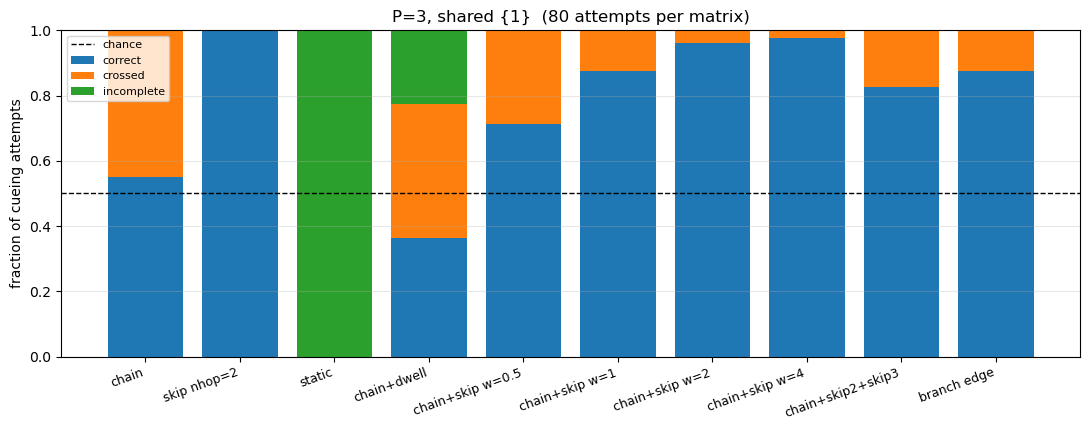

In [16]:
print("P = 3, shared {1}")
out_e1, _ = rule_sweep(rule_catalogue(3, shared_run=1), 3, (1,), duration=60.0)
plot_rule_outcomes(out_e1, "P=3, shared {1}")
plt.tight_layout(); plt.show()

## Experiment 2 — $P=5$, one crossover at index 2

Two patterns of run-up before the branch, two more transitions after it. $A[1]$ is still
unshared and still sits directly before the crossover, so a hop of 2 is still decisive.

P = 5, shared {2}


chain                correct=   2%  crossed=  41%  incomplete=  56%


skip nhop=2          correct=   0%  crossed=  24%  incomplete=  76%


static               correct=   0%  crossed=   0%  incomplete= 100%


chain+dwell          correct=   4%  crossed=  46%  incomplete=  50%


...

chain+skip w=1       correct=   0%  crossed=  25%  incomplete=  75%


chain+skip w=2       correct=   0%  crossed=  21%  incomplete=  79%


chain+skip w=4       correct=   0%  crossed=  22%  incomplete=  78%


chain+skip2+skip3    correct=   0%  crossed=  21%  incomplete=  79%


branch edge          correct=   0%  crossed=   8%  incomplete=  92%


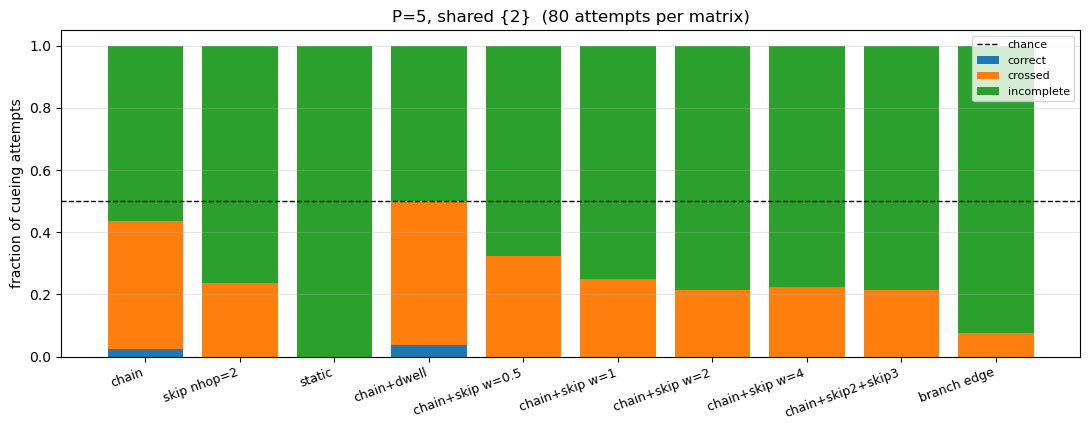

In [17]:
print("P = 5, shared {2}")
out_e2, first_e2 = rule_sweep(rule_catalogue(5, shared_run=1), 5, (2,), duration=100.0)
plot_rule_outcomes(out_e2, "P=5, shared {2}")
plt.tight_layout(); plt.show()

## Experiment 3 — $P=5$, shared run of 3

Sixty percent of each sequence is shared. `branch edge` is rebuilt with `shared_run=3`, so its
hop is `nhop` = 4. Every other member reaches at most 3.

P = 5, shared {1, 2, 3}


chain                correct=  46%  crossed=  39%  incomplete=  15%


skip nhop=2          correct=  52%  crossed=  48%  incomplete=   0%


static               correct=   0%  crossed=   0%  incomplete= 100%


chain+dwell          correct=  22%  crossed=  25%  incomplete=  52%


...

chain+skip w=1       correct=  51%  crossed=  46%  incomplete=   2%


chain+skip w=2       correct=  52%  crossed=  48%  incomplete=   0%


chain+skip w=4       correct=  51%  crossed=  49%  incomplete=   0%


chain+skip2+skip3    correct=  52%  crossed=  45%  incomplete=   2%


branch edge          correct=  79%  crossed=  21%  incomplete=   0%


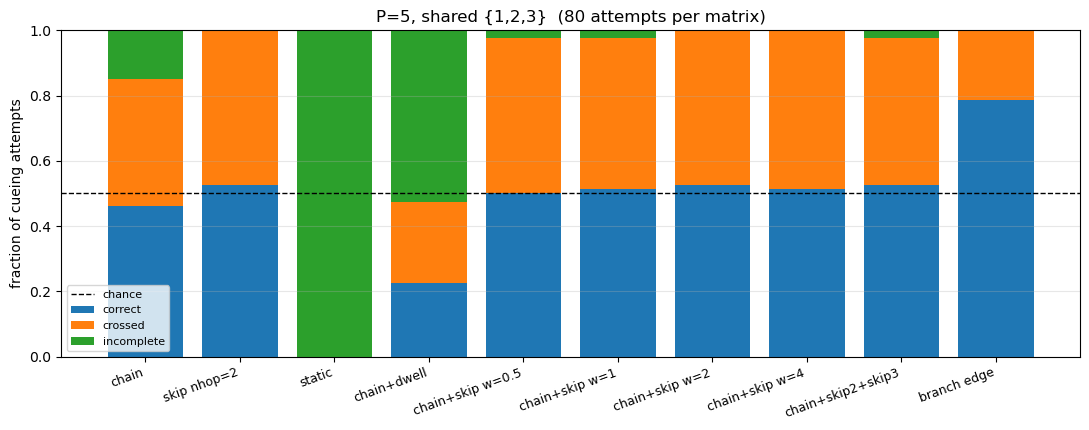

In [18]:
print("P = 5, shared {1, 2, 3}")
out_e3, first_e3 = rule_sweep(rule_catalogue(5, shared_run=3), 5, (1, 2, 3), duration=100.0)
plot_rule_outcomes(out_e3, "P=5, shared {1,2,3}")
plt.tight_layout(); plt.show()

---

## Knob 1 — the weights

### The $\Sigma^{(2)}$ weight

$\Sigma + w\,\Sigma^{(2)}$, pulled out of the three experiments. $w=0$ is the plain chain and
larger $w$ means the pattern two back speaks more loudly. This is Part I's skip-weight scan,
read across three geometries.

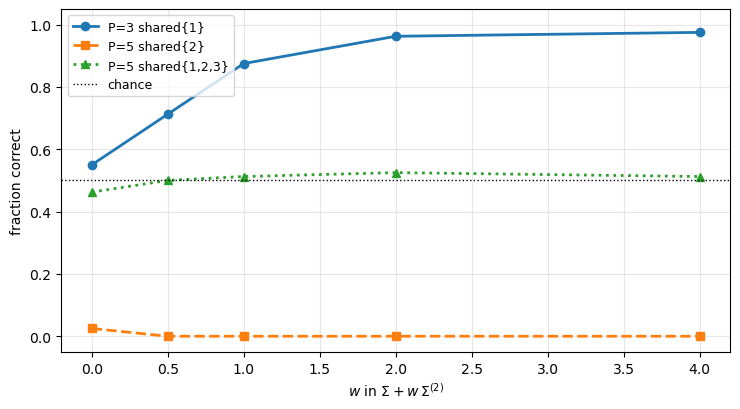

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
panels = [("P=3 shared{1}", out_e1, "-o"), ("P=5 shared{2}", out_e2, "--s"),
          ("P=5 shared{1,2,3}", out_e3, ":^")]
for tag, rule_outcomes, style in panels:
    keys = ["chain"] + [f"chain+skip w={w:g}" for w in W_VALUES[1:]]
    attempts = sum(rule_outcomes[keys[0]].values())
    ax.plot(W_VALUES, [rule_outcomes[k]["correct"] / attempts for k in keys], style, lw=2, label=tag)
ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
ax.set_xlabel(r"$w$ in $\Sigma + w\,\Sigma^{(2)}$")
ax.set_ylabel("fraction correct")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Two weights at once

`chain+skip2+skip3` has two, so sweep both: $T = \Sigma + w_1\Sigma^{(2)} + w_2\Sigma^{(3)}$. The
$w_2=0$ column is the `chain+skip` line already scanned and the $w_1=w_2=0$ corner is the
plain chain, so this generalizes the previous plot rather than repeating it. `lag_matrix`
normalizes by the total weight, so raising one weight dilutes the other's share.

P = 5, shared {2}      w2=0     w2=0.5   w2=1     w2=2     
  w1=0                      3%      0%      0%      0%
  w1=0.5                    0%      0%      0%      0%
  w1=1                      0%      0%      0%      0%
  w1=2                      0%      0%      0%      0%



P = 5, shared {1,2,3}      w2=0     w2=0.5   w2=1     w2=2     
  w1=0                     50%     55%     57%     50%
  w1=0.5                   52%     55%     58%     52%
  w1=1                     57%     55%     57%     50%
  w1=2                     53%     55%     57%     53%



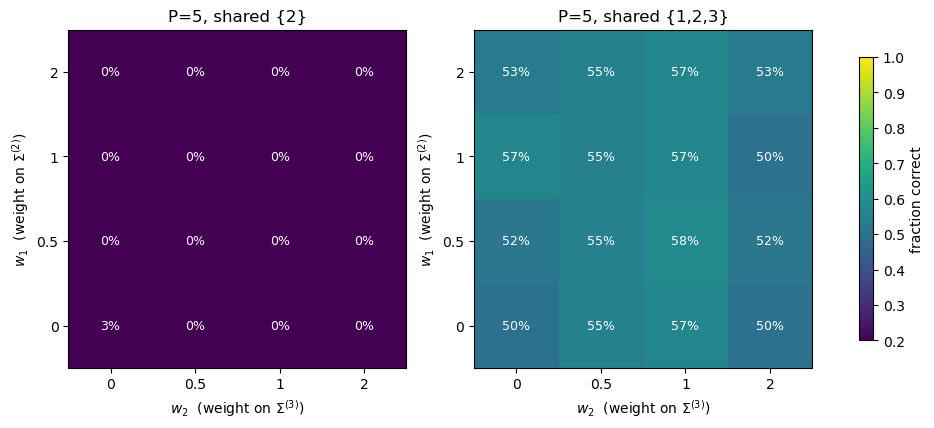

In [20]:
GRID_W = [0.0, 0.5, 1.0, 2.0]

grid_out = {}
for tag, shared in [("shared {2}", (2,)), ("shared {1,2,3}", (1, 2, 3))]:
    catalogue = {(w1, w2): lag_matrix(5, [1.0, w1, w2]) for w1 in GRID_W for w2 in GRID_W}
    grid_out[tag] = rule_sweep(catalogue, 5, shared, 100.0, trials=30, verbose=False)[0]
    print(f"P = 5, {tag}      " + "".join(f"w2={w2:<6g}" for w2 in GRID_W))
    for w1 in GRID_W:
        row = "".join(f"{grid_out[tag][(w1, w2)]['correct'] / sum(grid_out[tag][(w1, w2)].values()):>8.0%}"
                      for w2 in GRID_W)
        print(f"  w1={w1:<5g}            {row}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (tag, rule_outcomes) in zip(axes, grid_out.items()):
    grid = np.array([[rule_outcomes[(w1, w2)]["correct"] / sum(rule_outcomes[(w1, w2)].values())
                      for w2 in GRID_W] for w1 in GRID_W])
    im = ax.imshow(grid, cmap="viridis", vmin=0.2, vmax=1.0, origin="lower")
    for i in range(len(GRID_W)):
        for j in range(len(GRID_W)):
            ax.text(j, i, f"{grid[i, j]:.0%}", ha="center", va="center",
                    color="w" if grid[i, j] < 0.7 else "k", fontsize=9)
    ax.set_xticks(range(len(GRID_W)), [f"{w:g}" for w in GRID_W])
    ax.set_yticks(range(len(GRID_W)), [f"{w:g}" for w in GRID_W])
    ax.set_xlabel(r"$w_2$  (weight on $\Sigma^{(3)}$)")
    ax.set_ylabel(r"$w_1$  (weight on $\Sigma^{(2)}$)")
    ax.set_title(f"P=5, {tag}")
fig.colorbar(im, ax=axes, label="fraction correct", shrink=0.8)
plt.show()

On `shared {2}`, $w_2$ dominates and $w_1$ barely matters. The reason is which pattern each
hop lands on. With $A=[a_0,a_1,s,a_3,a_4]$, $\Sigma^{(2)}$ contributes $T[3,1]$, the edge
$a_1 \rightarrow a_3$, which is decisive but lands one step short of the end.
$\Sigma^{(3)}$ contributes $T[4,1]$, the edge $a_1 \rightarrow a_4$, which is decisive *and*
lands on the terminal pattern. A vote is worth most when it lands on the pattern whose
identity settles the branch.

On `shared {1,2,3}` no cell separates the branches. Neither $\Sigma^{(2)}$ nor $\Sigma^{(3)}$
contains $T[4,0]$, the only entry that can read the unshared $a_0$, and no setting of the
weights substitutes for hop length.

## Knob 2 — the hop length

$\Sigma + \Sigma^{(\texttt{nhop})}$, varying `nhop`. For a shared run at indices
$\ell \ldots h$ the decisive hop runs from the last unshared pattern before the run to the
first unshared one after it:

$$\texttt{nhop}_{\min} = (h+1)-(\ell-1) = L+1, \qquad L = \text{run length}.$$

That is 2 for a single crossover and 4 for a run of three. Below the threshold the added hop
lands on a pattern that is itself shared, so it adds drive but no information about which
branch the trajectory came from. `boundary="self"` clamps rows past the end, so `nhop=5` is
the same matrix as `nhop=4` here.

P = 5, shared {2}   decisive hop at nhop = 2


nhop=2               correct=   0%  crossed=  25%  incomplete=  75%


nhop=3               correct=   0%  crossed=   8%  incomplete=  92%


nhop=4               correct=   0%  crossed=   2%  incomplete=  98%


nhop=5               correct=   0%  crossed=   2%  incomplete=  98%

P = 5, shared {1,2,3}   decisive hop at nhop = 4


nhop=2               correct=  51%  crossed=  46%  incomplete=   2%


nhop=3               correct=  51%  crossed=  49%  incomplete=   0%


nhop=4               correct=  79%  crossed=  21%  incomplete=   0%


nhop=5               correct=  79%  crossed=  21%  incomplete=   0%

Sigma^(2) at P=5   T[4,0] = 0
[[0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 1 1]] 

Sigma^(3) at P=5   T[4,0] = 0
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]
 [0 1 1 1 1]] 

Sigma^(4) at P=5   T[4,0] = 1
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]] 

Sigma^(5) at P=5   T[4,0] = 1
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]] 



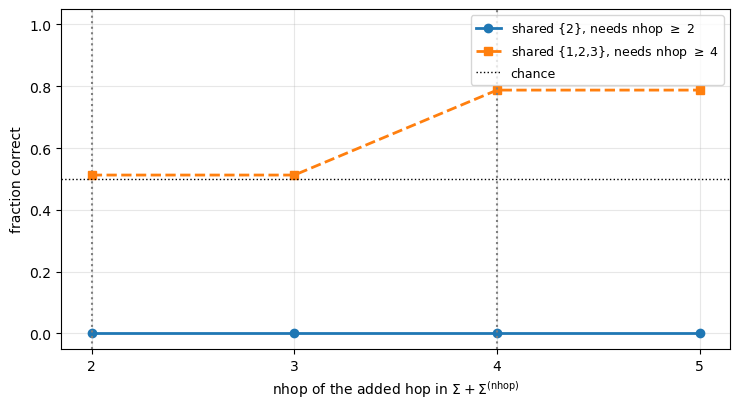

In [21]:
NHOPS = [2, 3, 4, 5]

reach_out = {}
for tag, shared in [("shared {2}", (2,)), ("shared {1,2,3}", (1, 2, 3))]:
    need = max(shared) + 1 - (min(shared) - 1)
    print(f"P = 5, {tag}   decisive hop at nhop = {need}")
    reach_out[tag] = rule_sweep(
        {f"nhop={h}": lag_matrix(5, [1.0] + [0.0] * (h - 2) + [1.0]) for h in NHOPS},
        5, shared, 100.0)[0]
    print()

for h in NHOPS:
    print(f"Sigma^({h}) at P=5   T[4,0] = {ktr.shift_transition(5, nhop=h)[4, 0]:.0f}")
    print(ktr.shift_transition(5, nhop=h).astype(int), "\n")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for (tag, rule_outcomes), style, need in zip(reach_out.items(), ("-o", "--s"), (2, 4)):
    attempts = sum(rule_outcomes["nhop=2"].values())
    ax.plot(NHOPS, [rule_outcomes[f"nhop={h}"]["correct"] / attempts for h in NHOPS],
            style, lw=2, label=f"{tag}, needs nhop $\\geq$ {need}")
    ax.axvline(need, color="tab:grey", ls=":", lw=1.5)
ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
ax.set_xlabel(r"nhop of the added hop in $\Sigma + \Sigma^{(\mathrm{nhop})}$")
ax.set_xticks(NHOPS)
ax.set_ylabel("fraction correct")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### The weight on the decisive hop

The scan above fixes the added hop at weight 1. Sweeping it,
$T = \Sigma + w\,\Sigma^{(L+1)}$, asks whether the hop merely has to exist or has to be loud.

P = 5, shared {2}   hop at nhop = 2


w=0.25               correct=   0%  crossed=  29%  incomplete=  71%


w=0.5                correct=   0%  crossed=  16%  incomplete=  84%


w=1                  correct=   0%  crossed=   8%  incomplete=  92%


w=2                  correct=   0%  crossed=   2%  incomplete=  98%


...

w=0.25               correct=  50%  crossed=  45%  incomplete=   5%


w=0.5                correct=  65%  crossed=  35%  incomplete=   0%


w=1                  correct=  79%  crossed=  21%  incomplete=   0%


w=2                  correct=  86%  crossed=  14%  incomplete=   0%


w=4                  correct=  92%  crossed=   8%  incomplete=   0%



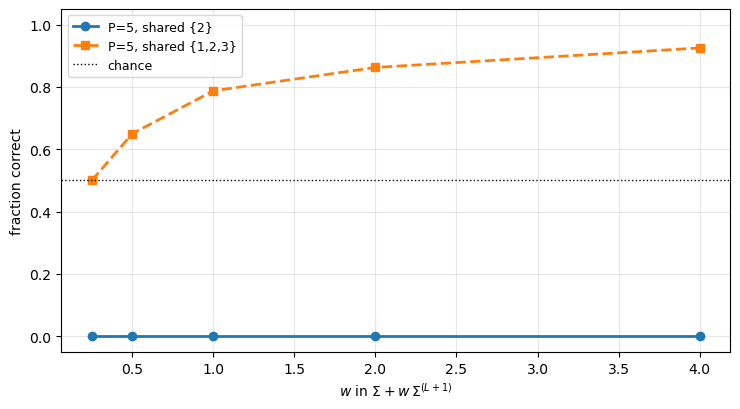

In [22]:
EDGE_W = [0.25, 0.5, 1.0, 2.0, 4.0]

edge_out = {}
for tag, shared, run in [("shared {2}", (2,), 1), ("shared {1,2,3}", (1, 2, 3), 3)]:
    print(f"P = 5, {tag}   hop at nhop = {run + 1}")
    edge_out[tag] = rule_sweep(
        {f"w={w:g}": lag_matrix(5, [1.0] + [0.0] * run + [w]) for w in EDGE_W},
        5, shared, 100.0)[0]
    print()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for (tag, rule_outcomes), style in zip(edge_out.items(), ("-o", "--s")):
    attempts = sum(rule_outcomes[f"w={EDGE_W[0]:g}"].values())
    ax.plot(EDGE_W, [rule_outcomes[f"w={w:g}"]["correct"] / attempts for w in EDGE_W],
            style, lw=2, label=f"P=5, {tag}")
ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
ax.set_xlabel(r"$w$ in $\Sigma + w\,\Sigma^{(L+1)}$")
ax.set_ylabel("fraction correct")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

It has to be loud. The hop competes against the chain term, which drives *both* branches
symmetrically out of the shared run, so the branch-specific vote has to outweigh it rather
than merely join it. `branch edge` as listed in `rule_catalogue`, at $w=1$, understates what
the rule can do.

## Trial 0 under the chain and the branch edge

Read the tail of each panel: under the chain the two terminal overlaps rise together out of
the shared region, which is the ambiguity itself.

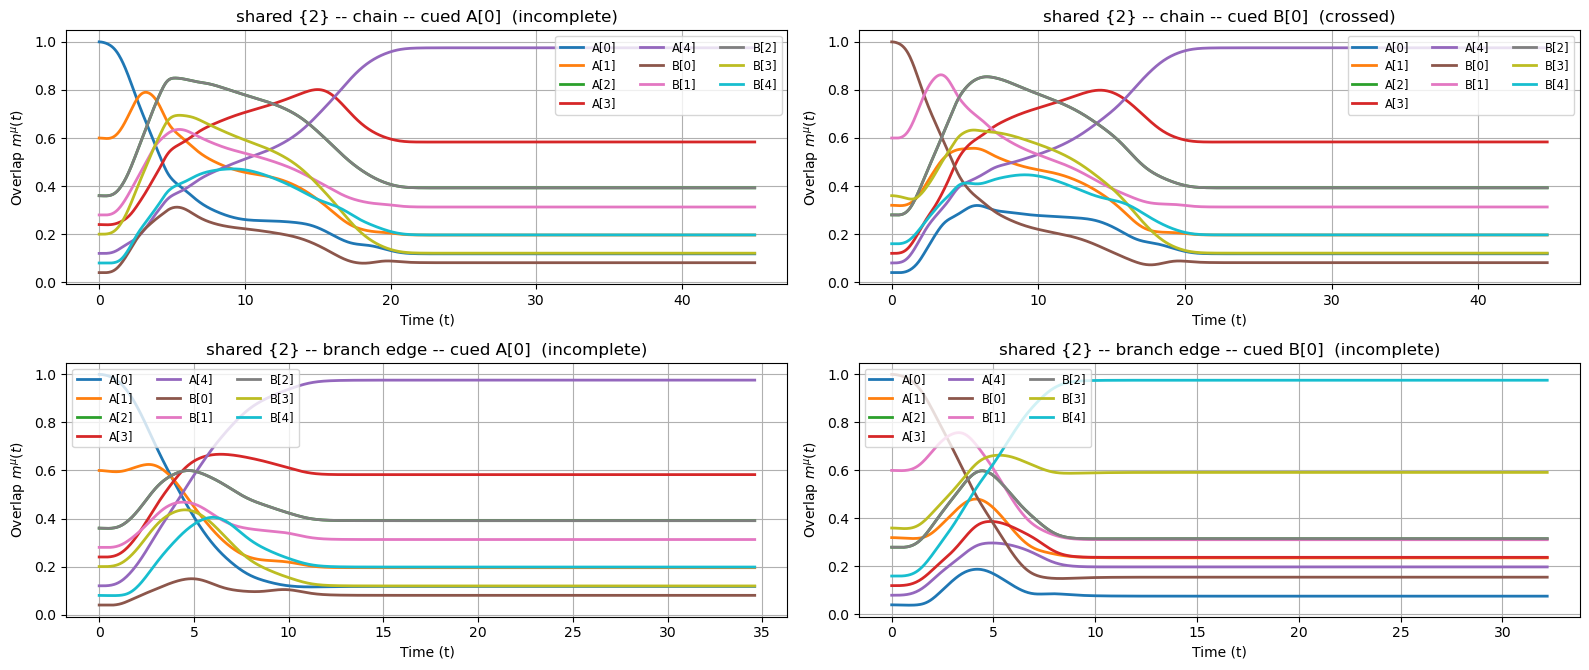

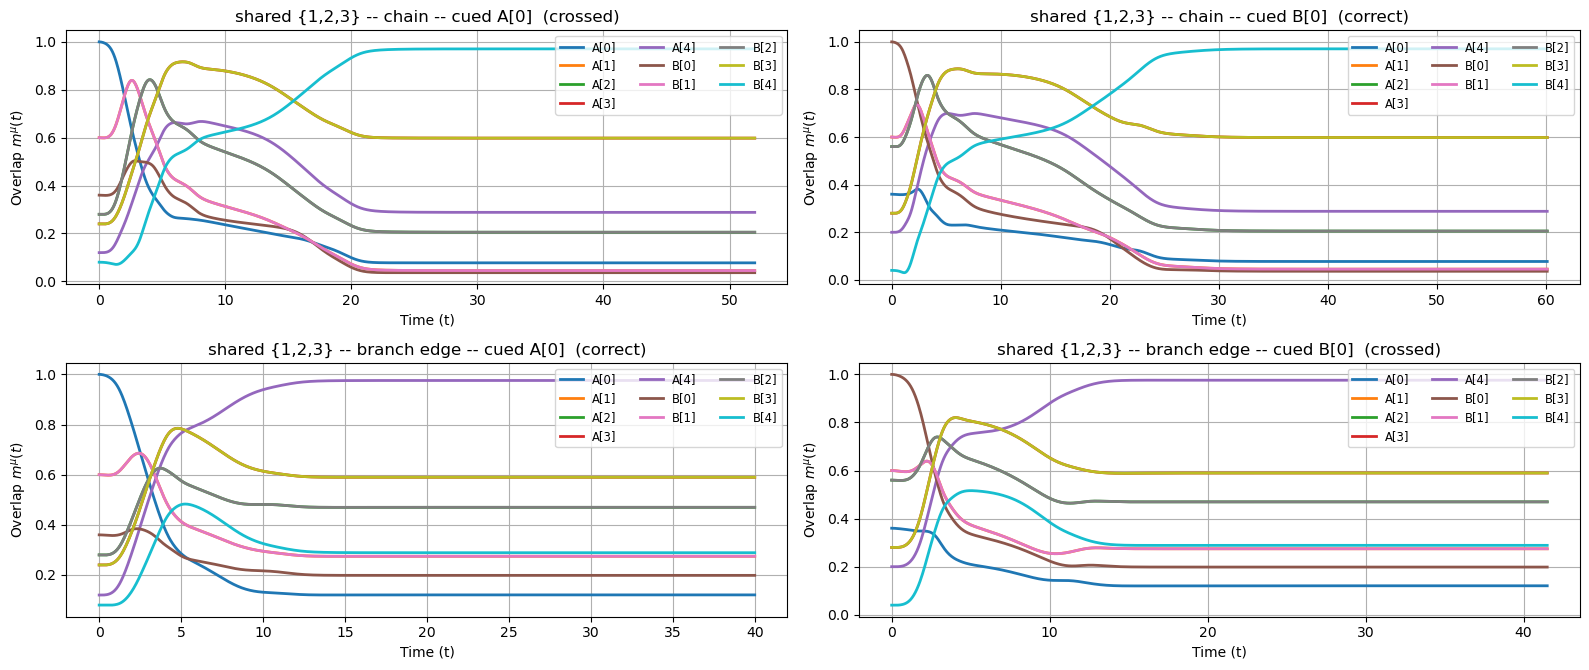

In [23]:
for first, tag in [(first_e2, "shared {2}"), (first_e3, "shared {1,2,3}")]:
    picked = ["chain", "branch edge"]
    fig, axes = plt.subplots(len(picked), 2, figsize=(16, 3.4 * len(picked)))
    for row, rule in enumerate(picked):
        net, multi, out = first[rule]
        for col, name in enumerate(("A", "B")):
            net.plot(out[name]["result"], multi, ax=axes[row, col],
                     title=f"{tag} -- {rule} -- cued {name}[0]  ({out[name]['outcome']})")
    plt.tight_layout(); plt.show()

---

# Part III — 100 seeds at a sampled corruption rate

Every sweep so far used exactly `CONFIG["corruption_rate"]`, which tests the rules at one
operating point. Here the rate is **drawn once per seed** and used for every mutation in that
trial's sequences, so each of the 100 trials is an internally consistent instance at its own
difficulty, and the difficulty varies across trials.

This is harder than redrawing the rate at every mutation would be: a sequence built entirely
at 0.28 has *every* consecutive pair 28% apart, where per-mutation draws would average out
within the sequence. Expect a higher `incomplete` fraction than in Part II.

`krm.corrupt_phase` turns a rate into a flip count with `int(rate * N)`, which truncates and
so lands below the requested rate on average. `sample_corruption_rate` rounds the count
stochastically instead, so its expectation is the requested rate and the mean over the 100
seeds converges to the target. It returns a rate that `corrupt_phase` truncates to exactly
that count, so `make_crossover_multisequence3` is used unchanged.

In [24]:
CORRUPTION_TARGET = CONFIG["corruption_rate"]   # 0.2
CORRUPTION_SPREAD = 0.08                        # per-seed rate ~ U[0.12, 0.28]
SEED_TRIALS       = 100

def sample_corruption_rate(target, spread, N, rng):
    """One corruption rate, stochastically rounded to a whole flip count.

    Returns (k + 0.5)/N so that corrupt_phase's int() truncation lands on exactly k, where
    k = floor(rN) + Bernoulli(frac(rN)) and so E[k] = rN."""
    rate = rng.uniform(target - spread, target + spread)
    exact = rate * N
    floor = np.floor(exact)
    flips = int(floor + (rng.random() < exact - floor))
    return (flips + 0.5) / N


def seed_sweep(catalogue, seq_len, shared_idx, duration, trials=SEED_TRIALS, seed=0):
    """`rule_sweep` with one corruption rate drawn per trial instead of a fixed one.

    Every matrix is re-seeded to the same value, so all of them see the identical instances
    at the identical rates."""
    rule_outcomes = {}
    for rule, T in catalogue.items():
        net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
        rng = np.random.default_rng(seed)
        counter = Counter()
        for _ in range(trials):
            rate = sample_corruption_rate(CORRUPTION_TARGET, CORRUPTION_SPREAD, N, rng)
            origin_seed = int(rng.integers(SEED_POOL))
            mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
            multi = make_crossover_multisequence3(N, rate, origin_seed, mutation_seeds,
                                                  seq_len, shared_idx)
            for name in ("A", "B"):
                result = net.simulate(multi, cue=multi[name], cue_idx=0, T=duration)
                retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
                counter[classify_unshared(retrieved, multi, name, shared_idx)] += 1
        rule_outcomes[rule] = counter
        attempts = sum(counter.values())
        print(f"{rule:<20} correct={counter['correct'] / attempts:>5.0%}  "
              f"crossed={counter['crossed'] / attempts:>5.0%}  "
              f"incomplete={counter['incomplete'] / attempts:>5.0%}")
    return rule_outcomes

In [25]:
print(f"P = 5, shared {{2}} -- {SEED_TRIALS} seeds")
seed_out_1 = seed_sweep(rule_catalogue(5, shared_run=1), 5, (2,), duration=100.0)
print()
print(f"P = 5, shared {{1,2,3}} -- {SEED_TRIALS} seeds")
seed_out_3 = seed_sweep(rule_catalogue(5, shared_run=3), 5, (1, 2, 3), duration=100.0)

P = 5, shared {2} -- 100 seeds


chain                correct=   5%  crossed=  36%  incomplete=  58%


skip nhop=2          correct=   0%  crossed=  21%  incomplete=  79%


static               correct=   0%  crossed=   0%  incomplete= 100%


chain+dwell          correct=   4%  crossed=  32%  incomplete=  64%


...

chain+skip w=1       correct=  42%  crossed=  38%  incomplete=  20%


chain+skip w=2       correct=  44%  crossed=  38%  incomplete=  18%


chain+skip w=4       correct=  44%  crossed=  42%  incomplete=  14%


chain+skip2+skip3    correct=  40%  crossed=  38%  incomplete=  22%


branch edge          correct=  60%  crossed=  24%  incomplete=  15%


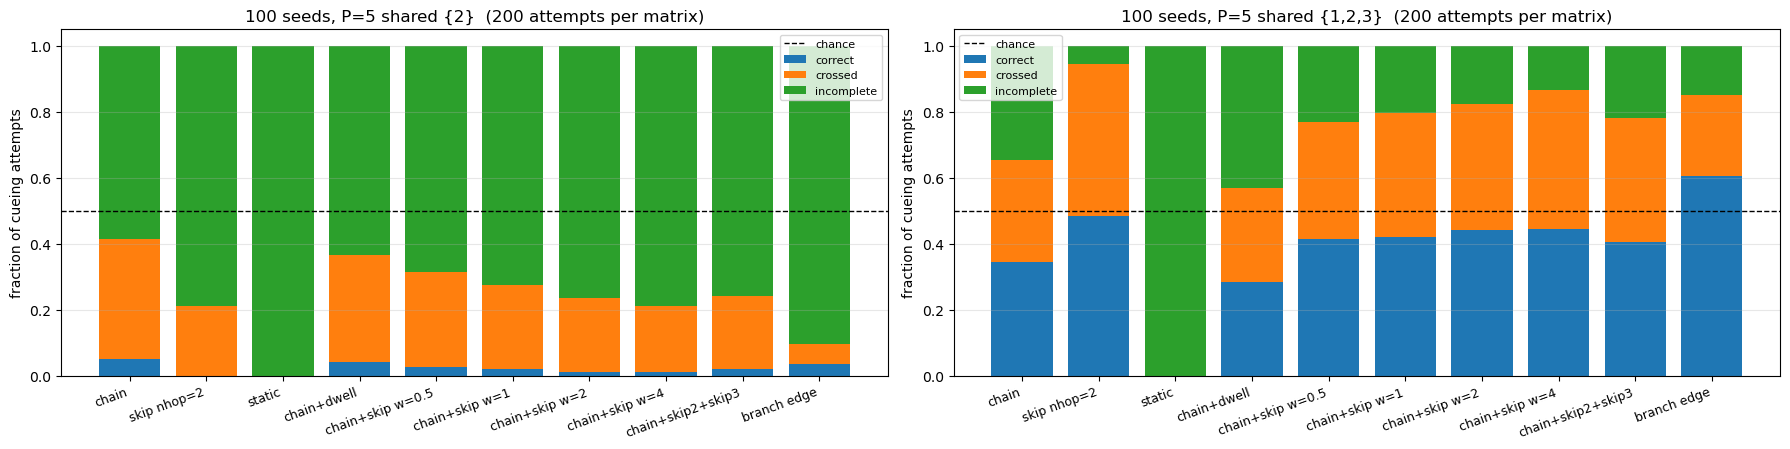

matrix                  shared {2}    shared {1,2,3}     (fraction correct)
-------------------------------------------------------
chain                           5%               34%
skip nhop=2                     0%               48%
static                          0%                0%
chain+dwell                     4%               28%
chain+skip w=0.5                2%               42%
chain+skip w=1                  2%               42%
chain+skip w=2                  1%               44%
chain+skip w=4                  1%               44%
chain+skip2+skip3               2%               40%
branch edge                     4%               60%


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4.6))
plot_rule_outcomes(seed_out_1, f"{SEED_TRIALS} seeds, P=5 shared {{2}}", ax=axes[0])
plot_rule_outcomes(seed_out_3, f"{SEED_TRIALS} seeds, P=5 shared {{1,2,3}}", ax=axes[1])
plt.tight_layout(); plt.show()

print(f"{'matrix':<20}{'shared {2}':>14}{'shared {1,2,3}':>18}     (fraction correct)")
print("-" * 55)
for rule in seed_out_1:
    a1 = sum(seed_out_1[rule].values()); a3 = sum(seed_out_3[rule].values())
    print(f"{rule:<20}{seed_out_1[rule]['correct'] / a1:>14.0%}{seed_out_3[rule]['correct'] / a3:>18.0%}")

---

# Part IV — Self-reference vs. loop

Every matrix so far has used `boundary="self"`. `ktr.shift_transition` offers two ways to
resolve the end of the chain, and the note under *Reading the matrices* above already names
the difference as a single entry:

- `boundary="self"` clamps rows that run off the end, so $T[P{-}1,P{-}1]=1$. The terminal
  pattern drives itself and the trajectory settles there.
- `boundary="cycle"` wraps them, so $T[0,P{-}1]=1$. The terminal pattern drives the first
  one and the sequence is meant to loop.

`lag_matrix` and `rule_catalogue` both take `boundary`, so the comparison is a keyword. Below,
the plain chain under both: how many steps ran before the stationary break fired, the peak
overlap with the cued branch's terminal pattern, and the outcome counts. A single sequence
with no crossover is included so that "cycling is hard" and "cycling plus a branch is hard"
can be told apart.

In [27]:
BOUNDARY_T = 150.0
BOUNDARY_TRIALS = 12
full_steps = int(BOUNDARY_T / CONFIG["dt"]) + 1

control = krm.generate_multi_sequence(N=N, seq_len=4, corruption_rate=CONFIG["corruption_rate"],
                                      count=1, seed=7)

print(f"full schedule = {full_steps} steps; fewer means the trajectory settled\n")
print(f"{'geometry':<18}{'boundary':<10}{'steps':>7}{'peak m':>9}   outcomes")
print("-" * 70)

for tag, shared in [("control (1 seq)", None), ("shared {2}", (2,)), ("shared {1,2,3}", (1, 2, 3))]:
    for boundary in ("self", "cycle"):
        net = ktr.TransitionNetwork(transition=lag_matrix(5, [1.0], boundary=boundary),
                                    N=N, seed=10, **CONFIG)
        steps, peaks, counter = [], [], Counter()
        rng = np.random.default_rng(0)
        for _ in range(BOUNDARY_TRIALS):
            if shared is None:
                sequences, cues = control, ("A",)
            else:
                sequences = make_crossover_multisequence3(
                    N, CONFIG["corruption_rate"], int(rng.integers(SEED_POOL)),
                    rng.choice(SEED_POOL, size=12, replace=False).tolist(), 5, shared)
                cues = ("A", "B")
            for name in cues:
                result = net.simulate(sequences, cue=sequences[name], cue_idx=0, T=BOUNDARY_T)
                overlaps = net.overlaps(result["theta_history"], sequences)
                own = sequences.labels().index((name, 4))
                steps.append(result["theta_history"].shape[0])
                peaks.append(overlaps[:, own].max())
                if shared is not None:
                    retrieved = net.decode_sequence_online(result, sequences, margin=MARGIN)
                    counter[classify_unshared(retrieved, sequences, name, shared)] += 1
        total_c = sum(counter.values())
        summary = "  ".join(f"{k}={counter[k] / total_c:.0%}"
                            for k in kinds if counter[k]) or "n/a"
        print(f"{tag:<18}{boundary:<10}{np.mean(steps):>7.0f}{np.mean(peaks):>9.2f}   {summary}")
    print()

full schedule = 3001 steps; fewer means the trajectory settled

geometry          boundary    steps   peak m   outcomes
----------------------------------------------------------------------


control (1 seq)   self          688     0.98   n/a


control (1 seq)   cycle        3001     0.72   n/a



shared {2}        self          901     0.75   correct=8%  crossed=42%  incomplete=50%


shared {2}        cycle        3001     0.56   crossed=8%  incomplete=92%



shared {1,2,3}    self         1522     0.83   correct=54%  crossed=38%  incomplete=8%


shared {1,2,3}    cycle        3001     0.68   incomplete=100%



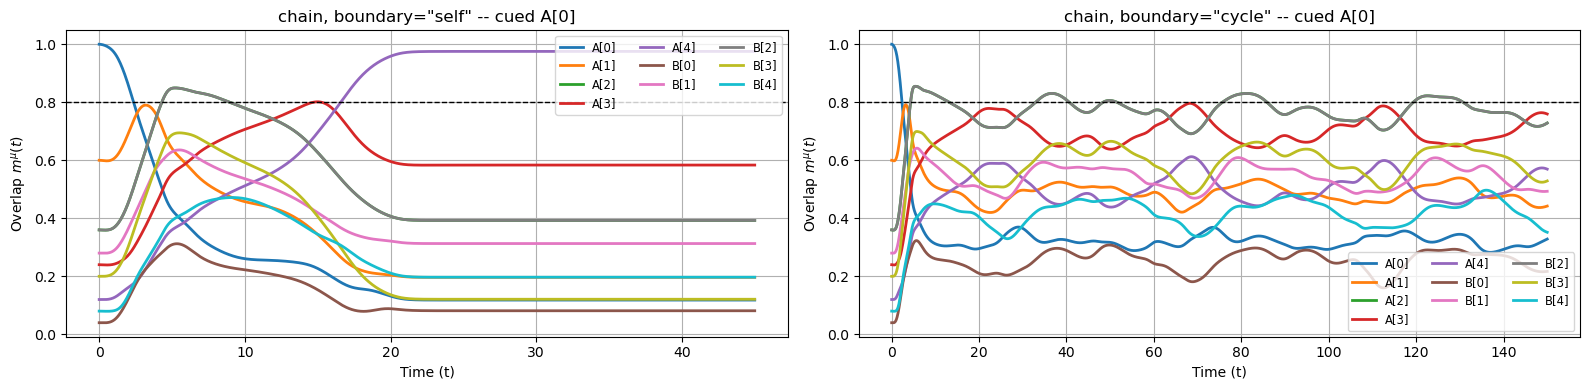

In [28]:
rng = np.random.default_rng(0)
trace_multi = make_crossover_multisequence3(
    N, CONFIG["corruption_rate"], int(rng.integers(SEED_POOL)),
    rng.choice(SEED_POOL, size=12, replace=False).tolist(), 5, (2,))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, boundary in zip(axes, ("self", "cycle")):
    net = ktr.TransitionNetwork(transition=lag_matrix(5, [1.0], boundary=boundary),
                                N=N, seed=10, **CONFIG)
    result = net.simulate(trace_multi, cue=trace_multi["A"], cue_idx=0, T=BOUNDARY_T)
    net.plot(result, trace_multi, ax=ax, title=f'chain, boundary="{boundary}" -- cued A[0]')
    ax.axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
plt.tight_layout(); plt.show()

**`self` settles and arrives.** The stationary break fires well inside the schedule and the
peak overlap with the terminal pattern is near 1.

**`cycle` never settles and never arrives.** It runs the full schedule every time and the
peak overlap stays below the `tolerance = 0.8` the decoder needs, so every attempt scores
`incomplete`. The state is not frozen, it drifts between patterns, but it circulates at
reduced amplitude instead of locking onto each pattern in turn.

**The control shows this is the boundary, not the crossover.** A single sequence with no
shared pattern behaves the same way.

The reason is in the matrices. Under `self`, $T[P{-}1,P{-}1]=1$ is the only diagonal entry in
the whole catalogue and the system's only fixed point. Under `cycle` every column points
strictly forward, no stored pattern is a fixed point of the drive, and nothing holds the
state still long enough for its overlap to build.

---



**1. The whole catalogue is one family: $T = \gamma I + \sum_k w_k \Sigma^{(k)}$.** Skips of
different lengths and their weighted sums, plus the static term. Part I's six matrices are six
points in it, and everything above is a sweep of the two knobs that matter here: which hop
lengths appear, and what weight each carries. Nothing outside that family is attempted: the
gate is a sum of pure powers of single overlaps, so a rule that needs two overlaps multiplied
together has no matrix and is not represented.

**3. No setting of the weights substitutes for hop length.** The grid over
$\Sigma + w_1\Sigma^{(2)} + w_2\Sigma^{(3)}$ separates nothing on the run-of-three geometry.
On the single crossover it does very well, and the useful weight is $w_2$, because
$\Sigma^{(3)}$ is the term whose decisive hop lands on the terminal pattern.

**4. A shared run of length $L$ needs a hop of `nhop` $=L+1$, and nothing shorter works.**
This is geometry, not statistics. Below the threshold the added hop lands on a pattern that is
itself shared, so it adds drive but no branch information.

*


**7. `boundary="cycle"` does not retrieve cleanly here, with or without a crossover.** `self`
works because $T[P{-}1,P{-}1]$ is the only diagonal entry and so the only fixed point. Under
`cycle` no stored pattern is a fixed point and the state circulates at an overlap too low to
clear `tolerance`. A single sequence with no shared pattern does the same.


## Where to change things (Parts II-IV)

- **Which rules are compared** — `rule_catalogue`: hops via `ktr.shift_transition`, dwell
  via `ktr.static_transition` / `ktr.mixed_transition`, sums via `lag_matrix`.
- **The geometry** — `seq_len` and `shared_idx` passed to `rule_sweep`. The shared run must be
  contiguous with at least one unshared pattern on each side.
- **The weights** — `W_VALUES`, `GRID_W`, `EDGE_W`.
- **The hop length** — `NHOPS`.
- **Sampled corruption** — `CORRUPTION_TARGET`, `CORRUPTION_SPREAD`, `SEED_TRIALS`.
- **Statistics** — `TRIALS`. Each trial is two integrations.
- **Settle vs. loop** — `boundary` on `lag_matrix` / `rule_catalogue`, compared in Part IV.